# 06 Modeling — Random Forest for Future Realized Volatility

This notebook trains a **Random Forest** to predict future realized volatility: given what we know about an asset today, predict how volatile it will be over the next 20 trading days (about one month).

We use the team's shared **feature-engineered dataset** produced by notebook 05, which already contains the engineered features and the prediction target. This is one half of the team's model comparison — another team member is training a **linear regression** on the same task. To make the comparison fair, both models must use the **same dataset, the same train/test split dates, and the same evaluation metrics** (R² and MAE on the held-out test set). Only the model differs.

Why a Random Forest as the contrast to linear regression?
- Linear regression assumes each feature has one constant, additive effect. A forest of decision trees can learn **nonlinear effects** (e.g., volatility mattering differently when it is extreme) and **interactions** (e.g., momentum meaning something different for bonds than for stocks) automatically.
- The performance gap between the two models is itself a finding: it measures how much nonlinearity actually exists in the data.

The model is trained as one pooled model on all 21 tickers together. Each row is one (date, ticker) observation, and ticker-specific behavior comes through the features (each ticker carries its own rolling volatility, momentum, and sector dummies).

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Paths

In [2]:
FEATURES_PATH = Path("../../data/processed/features")
MODELING_PATH = Path("../../data/processed/modeling")
MODEL_OUTPUT_PATH = MODELING_PATH / "random_forest"

MODEL_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)


# Load Feature-Engineered Dataset

We start from the team's shared feature-engineered dataset (long format: one row per date per ticker, features and target already computed, missing values already dropped).

In [3]:
df = pd.read_csv(
    FEATURES_PATH / "feature_engineered_dataset.csv",
    parse_dates=["Date"]
)

df = df.sort_values(["ticker", "Date"]).reset_index(drop=True)

print(df.shape)
df.head()

(41370, 30)


,Date,ticker,adjusted_close,daily_return,risk_free_rate_decimal,vix,treasury_10yr_pct,yield_curve_spread,is_inverted,fed_funds_rate_pct,...,rolling_return_20d,abs_return,squared_return,rolling_abs_return_20d,rolling_squared_return_20d,rolling_volatility_5d,rolling_volatility_20d,moving_avg_20d,price_to_moving_avg_20d,future_volatility_20d
0,2018-01-31,AAPL,39.138020,0.002755,0.0146,13.54,2.72,1.26,0,1.41,...,-0.001378,0.002755,0.000008,0.006855,0.000087,0.011013,0.009462,40.695438,0.961730,0.022707
1,2018-02-01,AAPL,39.219841,0.002091,0.0148,13.47,2.78,1.30,0,1.42,...,-0.001265,0.002091,0.000004,0.006951,0.000087,0.010065,0.009490,40.643427,0.964974,0.022726
2,2018-02-02,AAPL,37.518093,-0.043390,0.0148,17.31,2.84,1.36,0,1.42,...,-0.003667,0.043390,0.001883,0.008888,0.000180,0.019425,0.013250,40.496978,0.926442,0.019948
3,2018-02-05,AAPL,36.580715,-0.024985,0.0151,37.32,2.77,1.26,0,1.42,...,-0.005485,0.024985,0.000624,0.009568,0.000205,0.019936,0.013567,40.280635,0.908146,0.018715
4,2018-02-06,AAPL,38.109501,0.041792,0.0152,29.98,2.79,1.27,0,1.42,...,-0.003210,0.041792,0.001747,0.011472,0.000292,0.032292,0.017207,40.148329,0.949218,0.017050


# Select Features

The dataset has 30 columns, but not all of them belong in the model. We keep the features that carry forward-looking signal and drop the ones that are identifiers, redundant transformations, or risky:

**Kept:**
- `return_lag_1`, `return_lag_5` — recent individual returns (sign matters: volatility reacts more to drops than gains)
- `rolling_return_5d`, `rolling_return_20d` — short/medium momentum
- `rolling_volatility_5d`, `rolling_volatility_20d` — recent risk level, the main signal (volatility clustering)
- `rolling_abs_return_20d` — an alternative, outlier-robust volatility measure
- `price_to_moving_avg_20d` — trend position, unit-free
- `risk_free_rate_decimal`, `vix`, `treasury_10yr_pct`, `yield_curve_spread`, `is_inverted`, `fed_funds_rate_pct`, `unemployment_rate_pct`, `recession_flag`, `cpi_pct_change` — macro and risk context
- `gics_sector`, `asset_type` — one-hot encoded below, so the pooled model can tell asset classes apart

**Dropped, and why:**
- `Date`, `ticker`, `company_name` — identifiers, not features
- `adjusted_close`, `moving_avg_20d` — raw price *levels*; scale is arbitrary per ticker, and the useful trend information is already in the unit-free ratio `price_to_moving_avg_20d`
- `daily_return`, `abs_return`, `squared_return` — single-day values whose information is already captured by the lag and rolling features
- `rolling_squared_return_20d` — essentially the square of `rolling_volatility_20d`; same signal twice
- `cpi_index` — an ever-rising level that acts like a hidden date column, letting the model memorize time periods instead of learning economics; `cpi_pct_change` keeps the economic signal

In [4]:
NUMERIC_FEATURES = [
    "return_lag_1", "return_lag_5",
    "rolling_return_5d", "rolling_return_20d",
    "rolling_volatility_5d", "rolling_volatility_20d",
    "rolling_abs_return_20d",
    "price_to_moving_avg_20d",
    "risk_free_rate_decimal", "vix", "treasury_10yr_pct",
    "yield_curve_spread", "is_inverted", "fed_funds_rate_pct",
    "unemployment_rate_pct", "recession_flag", "cpi_pct_change",
]

df[NUMERIC_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
return_lag_1,41370.0,0.000602,0.015865,-0.223797,-0.006285,0.000743,0.007736,0.180125
return_lag_5,41370.0,0.000593,0.015864,-0.223797,-0.006304,0.000730,0.007725,0.180125
rolling_return_5d,41370.0,0.000598,0.006757,-0.063136,-0.002550,0.000691,0.004009,0.063674
rolling_return_20d,41370.0,0.000603,0.003238,-0.034983,-0.001051,0.000622,0.002367,0.018487
rolling_volatility_5d,41370.0,0.012643,0.009887,0.000215,0.006635,0.010263,0.015589,0.136568
rolling_volatility_20d,41370.0,0.013572,0.008335,0.000815,0.008519,0.011768,0.016599,0.085945
rolling_abs_return_20d,41370.0,0.010440,0.006326,0.000791,0.006708,0.009166,0.012636,0.072713
price_to_moving_avg_20d,41370.0,1.004807,0.036529,0.692237,0.986989,1.005850,1.024449,1.212206
risk_free_rate_decimal,41370.0,0.026521,0.020129,0.000000,0.003500,0.023650,0.044400,0.056300
vix,41370.0,19.891970,7.467051,10.850000,14.910000,17.995000,22.680000,82.690000


# The Target — `future_volatility_20d`

The target comes with the dataset: for a row on day *t*, it is the standard deviation of that ticker's daily returns over days *t+1* to *t+20* — strictly future information, computed per ticker in notebook 05, so there is no look-ahead leakage into the features. The last 20 days of each ticker (which have no complete future window) were already dropped upstream.

# Encode Categorical Metadata

One-hot encode sector and asset type. This is how the pooled model tells asset classes apart — bonds, gold, and tech stocks each get their own baseline volatility level.

In [5]:
df = pd.get_dummies(df, columns=["gics_sector", "asset_type"], drop_first=False)

dummy_columns = [c for c in df.columns if c.startswith(("gics_sector_", "asset_type_"))]
print(f"{len(dummy_columns)} dummy columns created")

18 dummy columns created


# Assemble Model Dataset

Combine the numeric features with the one-hot dummies, set the target, and keep a `dropna` as a safety net (the dataset arrives already cleaned, so it should drop nothing).

In [6]:
FEATURE_COLUMNS = NUMERIC_FEATURES + dummy_columns
TARGET_COLUMN = "future_volatility_20d"

model_df = df.dropna(subset=FEATURE_COLUMNS + [TARGET_COLUMN]).copy()

print("Rows before dropna:", len(df))
print("Rows after dropna:", len(model_df))
print("Features:", len(FEATURE_COLUMNS))

Rows before dropna: 41370
Rows after dropna: 41370
Features: 35


# Train/Test Split — By Date, Not By Row

We split chronologically: everything before 2024 is training data, 2024 onward is the held-out test set. A random shuffled split would leak the future into training (the model would see 2025 market conditions while being "tested" on 2024) and give fake-good scores.

All 21 tickers appear on both sides of the split — the split is on **time**, not on assets.

**NOTE:** `SPLIT_DATE` must match the linear regression notebook exactly, otherwise the two models are being tested on different data and the comparison means nothing.

In [7]:
SPLIT_DATE = "2024-01-01"

# TimeSeriesSplit later assumes rows are in chronological order, so sort by Date
model_df = model_df.sort_values("Date").reset_index(drop=True)

train_df = model_df[model_df["Date"] < SPLIT_DATE]
test_df = model_df[model_df["Date"] >= SPLIT_DATE]

X_train, y_train = train_df[FEATURE_COLUMNS], train_df[TARGET_COLUMN]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df[TARGET_COLUMN]

print(f"Train: {X_train.shape[0]} rows, {train_df['Date'].min().date()} to {train_df['Date'].max().date()}")
print(f"Test:  {X_test.shape[0]} rows, {test_df['Date'].min().date()} to {test_df['Date'].max().date()}")

Train: 31269 rows, 2018-01-31 to 2023-12-29
Test:  10101 rows, 2024-01-02 to 2025-12-01


# Baseline — Persistence

Before training anything, we need a baseline to beat. The simplest credible forecast of future volatility is **current volatility**: predict that the next 20 days will look like the last 20 days. Any model that can't beat this isn't adding value. Both team models should report this same baseline.

In [8]:
baseline_pred = test_df["rolling_volatility_20d"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Persistence baseline — R2: {baseline_r2:.4f}, MAE: {baseline_mae:.6f}")

Persistence baseline — R2: 0.0015, MAE: 0.004647


# How a Random Forest Works (Briefly)

A **decision tree** predicts by asking a sequence of yes/no questions about the features ("is `rolling_volatility_20d` > 0.012? → is `asset_type_ETF` true? → …") until it reaches a leaf, then predicts the average target of the training rows that landed in that leaf. A single deep tree memorizes the training data (overfits); a single shallow tree is too crude (underfits).

A **random forest** trains hundreds of trees, each on a random resample of the rows and a random subset of features at each split, then averages their predictions. The randomness makes the trees disagree in different ways, and averaging cancels out their individual overfitting.

Unlike linear/Ridge regression, no feature scaling is needed — trees only ask "greater or less than a threshold?", so the units of a feature don't matter.

The two hyperparameters we tune control tree complexity:
- **`max_depth`** — how many questions deep a tree may go. Deeper = more complex patterns, more overfitting risk.
- **`min_samples_leaf`** — how many training rows a leaf must contain. Larger = smoother, more conservative predictions.

In [9]:
param_grid = {
    "max_depth": [4, 8, 16, None],
    "min_samples_leaf": [1, 20, 100],
}

grid_search = GridSearchCV(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_mean_squared_error",
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)

Best params: {'max_depth': 8, 'min_samples_leaf': 1}


# Validation Curves — What Tuning Actually Does

Cross-validated error for every hyperparameter combination, using `TimeSeriesSplit` so validation folds always come **after** the data the fold trained on. Each line is one `min_samples_leaf` setting, plotted against `max_depth`. Look for the classic pattern: error falls as the trees get more expressive, then flattens or rises once they start overfitting.

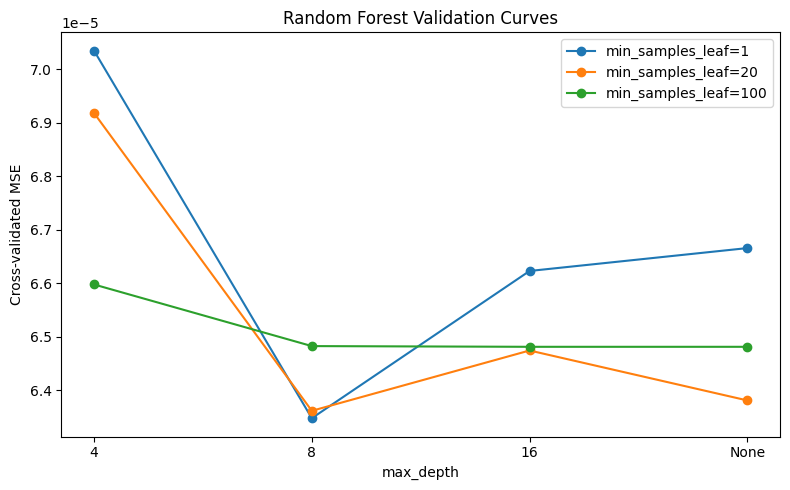

In [10]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results["mse"] = -cv_results["mean_test_score"]

# max_depth=None shows up as NaN here, and astype(str) leaves NaN as a float
# in pandas 3.x, which breaks matplotlib's string x-axis — build labels explicitly
cv_results["depth_label"] = ["None" if pd.isna(d) else str(int(d)) for d in cv_results["param_max_depth"]]

fig, ax = plt.subplots(figsize=(8, 5))
for leaf_size, group in cv_results.groupby("param_min_samples_leaf"):
    ax.plot(group["depth_label"], group["mse"], marker="o", label=f"min_samples_leaf={leaf_size}")
ax.set_xlabel("max_depth")
ax.set_ylabel("Cross-validated MSE")
ax.set_title("Random Forest Validation Curves")
ax.legend()
plt.tight_layout()
plt.show()

# Evaluate on the Held-Out Test Set

The tuned model now sees the 2024+ data for the first time. We compare against the persistence baseline — beating it means the model's features (momentum, volatility windows, macro, sector) add real predictive value. These same metrics can later be placed next to the linear regression model's results for the team comparison.

In [11]:
y_pred = grid_search.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)

comparison = pd.DataFrame({
    "model": ["Baseline: rolling_volatility_20d", "Random Forest (tuned)"],
    "MAE": [baseline_mae, rf_mae],
    "RMSE": [baseline_rmse, rf_rmse],
    "R2": [baseline_r2, rf_r2],
})

comparison

,model,MAE,RMSE,R2
0,Baseline: rolling_volatility_20d,0.004647,0.007130,0.001510
1,Random Forest (tuned),0.004062,0.006517,0.165752


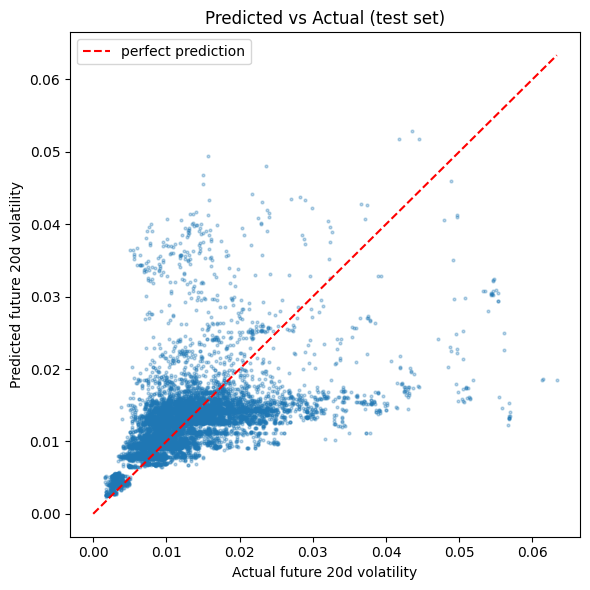

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, s=4, alpha=0.3)
limit = max(y_test.max(), y_pred.max())
ax.plot([0, limit], [0, limit], color="red", linestyle="--", label="perfect prediction")
ax.set_xlabel("Actual future 20d volatility")
ax.set_ylabel("Predicted future 20d volatility")
ax.set_title("Predicted vs Actual (test set)")
ax.legend()
plt.tight_layout()
plt.show()

# Which Features Matter?

Random forests report **feature importances**: how much each feature reduced prediction error across all the splits in all the trees (importances sum to 1). Expect the recent volatility features (`rolling_volatility_20d`, `rolling_volatility_5d`, `rolling_abs_return_20d`) to dominate — volatility clustering is the main signal.

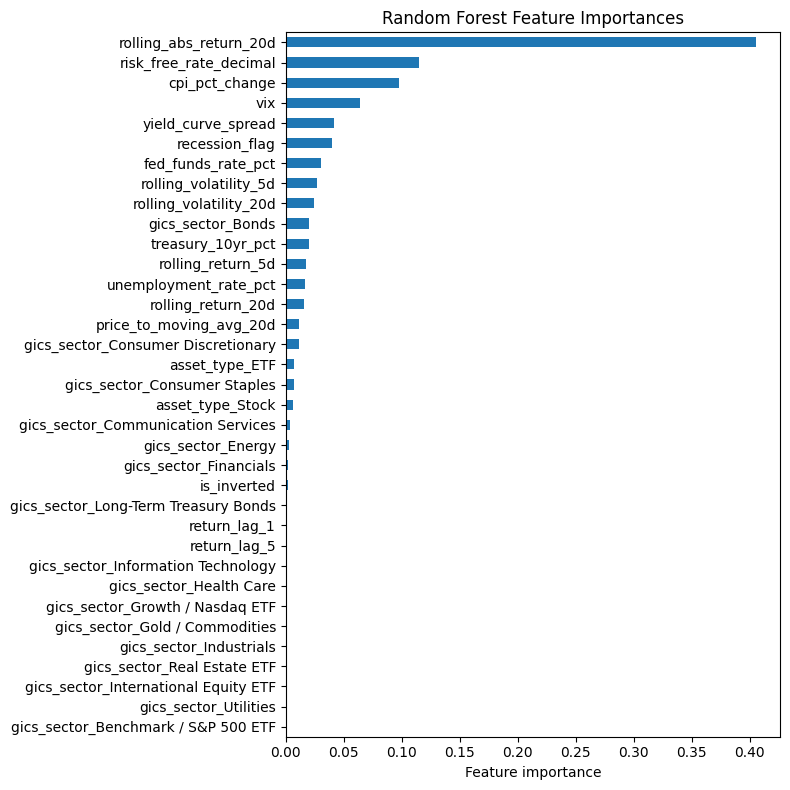

In [13]:
importances = (
    pd.Series(grid_search.best_estimator_.feature_importances_, index=FEATURE_COLUMNS)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 8))
importances.plot.barh(ax=ax)
ax.set_xlabel("Feature importance")
ax.set_title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# Sanity Check — Does the Pooled Model Distinguish Tickers?

One pooled model, but per-ticker inputs. If it were just predicting "average volatility," every ticker's predictions would look the same. Instead, quiet assets (AGG) should sit near zero and volatile ones (AAPL, AMZN) much higher.

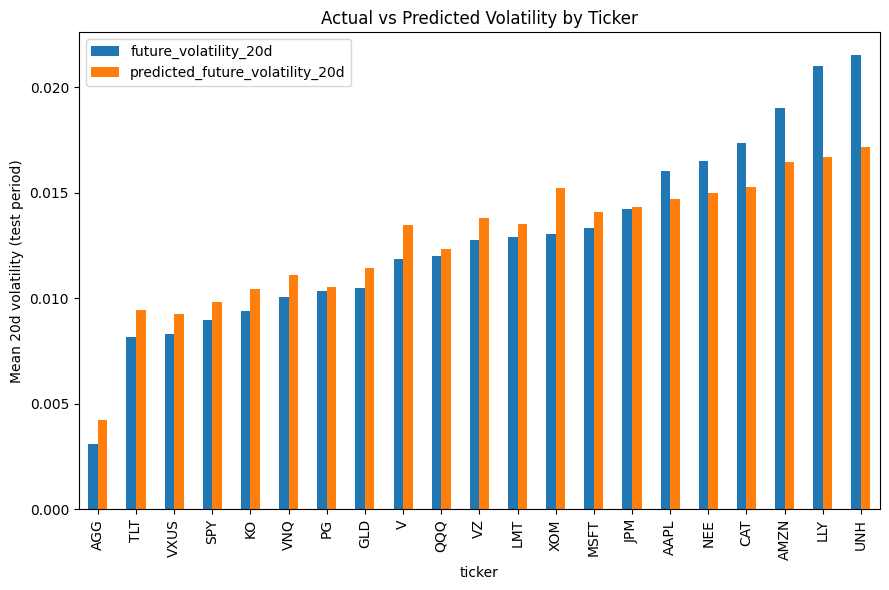

In [14]:
test_results = test_df.copy()
test_results["predicted_future_volatility_20d"] = y_pred

per_ticker = (
    test_results.groupby("ticker")[[TARGET_COLUMN, "predicted_future_volatility_20d"]]
    .mean()
    .sort_values(TARGET_COLUMN)
)

fig, ax = plt.subplots(figsize=(9, 6))
per_ticker.plot.bar(ax=ax)
ax.set_ylabel("Mean 20d volatility (test period)")
ax.set_title("Actual vs Predicted Volatility by Ticker")
plt.tight_layout()
plt.show()

# Save Test Predictions

Saved per-row so the two models' predictions can be compared side by side later (and fed into the portfolio/dashboard work).

In [15]:
output_columns = ["Date", "ticker", TARGET_COLUMN, "predicted_future_volatility_20d"]

test_results[output_columns].to_csv(
    MODEL_OUTPUT_PATH / "test_predictions.csv",
    index=False
)

comparison.to_csv(
    MODEL_OUTPUT_PATH / "metrics.csv",
    index=False
)

print("Saved:", MODEL_OUTPUT_PATH / "test_predictions.csv")
print("Saved:", MODEL_OUTPUT_PATH / "metrics.csv")


Saved: ..\..\data\processed\modeling\random_forest\test_predictions.csv
Saved: ..\..\data\processed\modeling\random_forest\metrics.csv


# Final Summary

In this notebook we:

- Loaded the team's shared feature-engineered dataset from notebook 05 (features and the `future_volatility_20d` target already computed per ticker, leakage-free)
- Selected the relevant feature columns, dropping identifiers, raw price levels, and redundant transformations
- Split train/test **by date** (train < 2024, test ≥ 2024) to avoid look-ahead bias
- Established a persistence baseline (future volatility = current `rolling_volatility_20d`)
- Trained one pooled Random Forest across all 21 tickers and tuned `max_depth` / `min_samples_leaf` with `GridSearchCV` + `TimeSeriesSplit`
- Compared the tuned model to the baseline on the held-out test set, and verified the pooled model distinguishes quiet assets from volatile ones

**For the team model comparison:** the linear regression notebook should use this same dataset, feature list, target, `SPLIT_DATE`, and metrics (test R² and MAE); its results can then be placed directly next to the numbers reported here. The gap between the two models measures how much nonlinearity the Random Forest found beyond the linear relationships.